### Dimensjonering av magasin og kostnad

In [1]:
#Import av nødvendige pakker

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import math

#### Magasinstørrelse og tverrsnittsareal

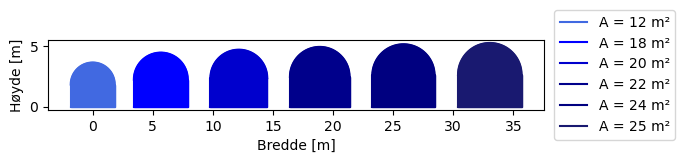

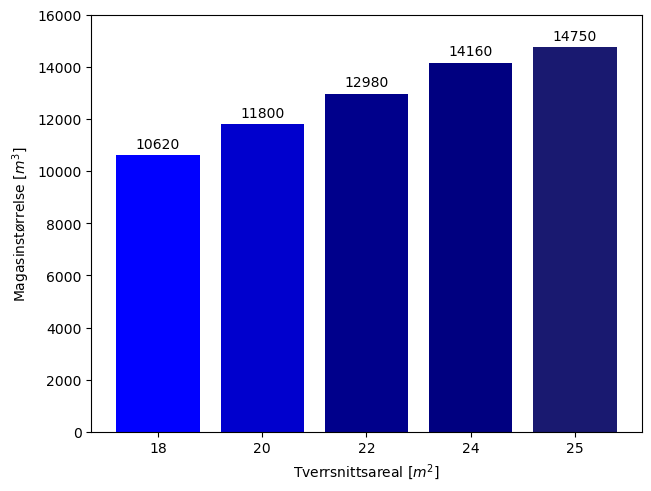

In [2]:
#Lengde tunnel
L = 590 #m

A_org = 12 #m^2

A1 = 18 #m^2
A2 = 20 #m^2
A3 = 22 #m^2
A4 = 24 #m^2
A5 = 25 #m^2



M1 = A1*L #m^3
M2 = A2*L #m^3
M3 = A3*L #m^3
M4 = A4*L #m^3
M5 = A5*L #m^3

#Grafisk fremstilling av tverrsnittsareal
arealer = [A_org, A1, A2, A3, A4, A5] # m²
                
farger = ['royalblue', 'blue', 'mediumblue', 'darkblue', 'navy', 'midnightblue']

theta = np.linspace(np.pi, 0, 300)

fig, ax = plt.subplots()

x_offset = 0.0                 # forskyvning mellom profilene
luft = 2.0                     # avstand mellom tverrsnitt

for A, farge in zip(arealer, farger):
    radius = np.sqrt(A*2/(4 + np.pi))
    bredde = 2*radius
    h = radius

    # Rektangel (vegg)
    x_rect = [
        x_offset - bredde/2,
        x_offset + bredde/2,
        x_offset + bredde/2,
        x_offset - bredde/2,
        x_offset - bredde/2
    ]
    y_rect = [0, 0, h, h, 0]

    # Hvelv (halvsirkel)
    x_arc = x_offset + radius * np.cos(theta)
    y_arc = h + radius * np.sin(theta)

    # Tegn kontur
    ax.plot(x_rect, y_rect, color=farge)
    ax.plot(x_arc, y_arc, color=farge, label=f"A = {round(A, 1)} m²")
   

    # Fyll tverrsnittet (valgfritt)
    ax.fill(x_rect, y_rect, color=farge)
    ax.fill(x_arc, y_arc, color=farge)

    # Flytt neste tverrsnitt
    x_offset += bredde + luft


ax.set_aspect("equal")
ax.set_xlabel("Bredde [m]")
ax.set_ylabel("Høyde [m]")
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)
plt.show()

#Grafisk fremstilling av magasinstørrelse

M = [M1, M2, M3, M4, M5]

arealer_M = [A1, A2, A3, A4, A5]

farger_M = ['blue', 'mediumblue', 'darkblue', 'navy', 'midnightblue']

x = np.arange(len(arealer_M))

fig, ax = plt.subplots(layout='constrained')

ax.bar(x, M, color=farger_M)
ax.bar_label(ax.containers[0], padding=3)

ax.set_ylabel('Magasinstørrelse [$m^3$]')
ax.set_xlabel('Tverrsnittsareal [$m^2$]')
ax.set_xticks(x)
ax.set_xticklabels(arealer_M)
ax.set_ylim(0, 16000)


plt.show()

#### Kostnadsberegninger

Kostnad for tunnel blir 19549 kr ved A = 12 for småkraftestimering
Kostnad for tunnel blir 23566 kr ved A = 12 for storkraftestimering
Kostnad for tunnel blir 26169 kr ved A = 18 for småkraftestimering
Kostnad for tunnel blir 25475 kr ved A = 18 for storkraftestimering
Kostnad for tunnel blir 27809 kr ved A = 20 for småkraftestimering
Kostnad for tunnel blir 26111 kr ved A = 20 for storkraftestimering
Kostnad for tunnel blir 29392 kr ved A = 22 for småkraftestimering
Kostnad for tunnel blir 26747 kr ved A = 22 for storkraftestimering
Kostnad for tunnel blir 31054 kr ved A = 24 for småkraftestimering
Kostnad for tunnel blir 27383 kr ved A = 24 for storkraftestimering
Kostnad for tunnel blir 31957 kr ved A = 25 for småkraftestimering
Kostnad for tunnel blir 27701 kr ved A = 25 for storkraftestimering


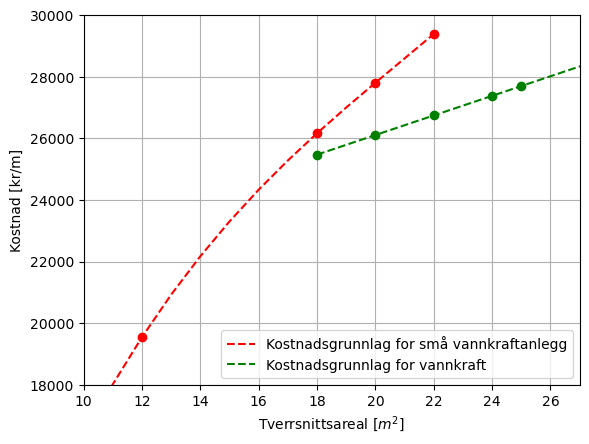

In [3]:
#Kostnadskurve fra NVE

#Kostnadskurve små kraftverk (10 - 22 m^2)
x1 = np.arange(7, 23)

#Kostnadskurve store kraftverk (fra 18 m^2)
x2 = np.arange(18, 51)

def y1(x):
    return (1.68*x**3 - 105*x**2 + 2654.5*x - 8055.6)*1.688

def y2(x):
    return (196.3*x + 12187)*0.96*1.688

plt.plot(x1, y1(x1), color='red', linestyle='--', label="Kostnadsgrunnlag for små vannkraftanlegg")
plt.plot(x2, y2(x2), color='green', linestyle='--', label="Kostnadsgrunnlag for vannkraft ")

for A in arealer:
    if A >= 18:
        plt.plot(A, y2(A), 'o', color='green')
        plt.plot(A, y1(A), 'o', color='red')
    else:
        plt.plot
        plt.plot(A, y1(A), 'o', color='red')
    
    print(f"Kostnad for tunnel blir {round(y1(A))} kr ved A = {A} for småkraftestimering")
        
    print(f"Kostnad for tunnel blir {round(y2(A))} kr ved A = {A} for storkraftestimering")


plt.xlabel('Tverrsnittsareal [$m^2$]')
plt.ylabel('Kostnad [kr/m]')

plt.xlim(10, 27)
plt.ylim(18000, 30000)
plt.legend()
plt.grid()
plt.show()

